In [1]:
print('test')

test


### 라벨 인코딩

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.inspection import permutation_importance
import joblib

In [13]:
df = pd.read_csv("../dataset/tips.csv")

In [14]:
print("===== 데이터 정보 =====")
print(df.info())
print(df.describe())

===== 데이터 정보 =====
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [15]:
# 2. Feature Engineering
#    (추가된 피처, 파생변수 : 기존에 없던 정보를 새로 만들어 모델 성능을 높이는 작업)
df['bill_per_person'] = df['total_bill'] / df['size']               # 1인당 금액
df['is_weekend'] = df['day'].isin(['Sat', 'Sun']).astype(int)       # 주말 여부
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)              # 저녁 여부
df['tip_rate'] = df['tip'] / df['total_bill']       # 팁 비율  
                                                    # 데이터 누수 : 타겟 데이터를 직접 줘버림

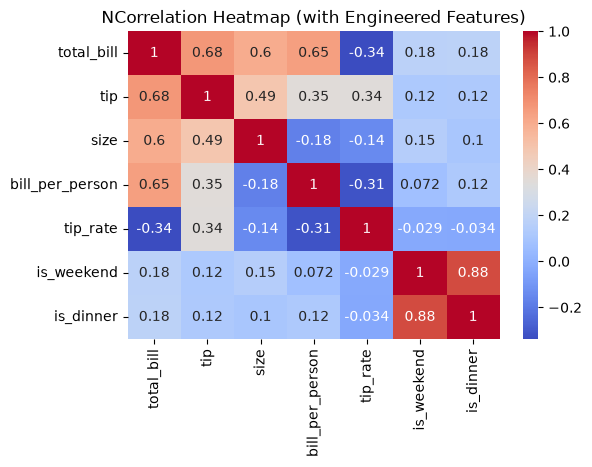

In [16]:
# 히트맵 분석 (수치형 + 파생변수 포함)
plt.figure(figsize=(6,4))
numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("NCorrelation Heatmap (with Engineered Features)")
plt.show()

In [17]:
# 4. 라벨 인코딩
# 범주형 컬럼 지정
categorical_cols = ['sex', 'smoker', 'day', 'time']

# 인코더 저장
encoders = {}

# 범주형 컬럼을 하나씩 숫자로 변환
for col in categorical_cols:
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    # 나중에 동일한 인코더를 사용하기 위해 저장
    encoders[col] = le
    
# 변환된 데이터 확인
print("Lable Encoding 변환 후:")
print(df.head())

Lable Encoding 변환 후:
   total_bill   tip  sex  ...  is_weekend  is_dinner  tip_rate
0       16.99  1.01    0  ...           1          1  0.059447
1       10.34  1.66    1  ...           1          1  0.160542
2       21.01  3.50    1  ...           1          1  0.166587
3       23.68  3.31    1  ...           1          1  0.139780
4       24.59  3.61    0  ...           1          1  0.146808

[5 rows x 11 columns]


In [ ]:
# 5. Feature / Target 분리
X = df.drop('tip', axis=1)
y = df['tip']

In [ ]:
# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# 7. 모델 학습
model = RandomForestRegressor(
    n_estimators=500, 
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train);

In [22]:
# 8. 예측 및 평가
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


===== 모델 성능 =====
R2 Score: 0.8221
RMSE: 0.4715


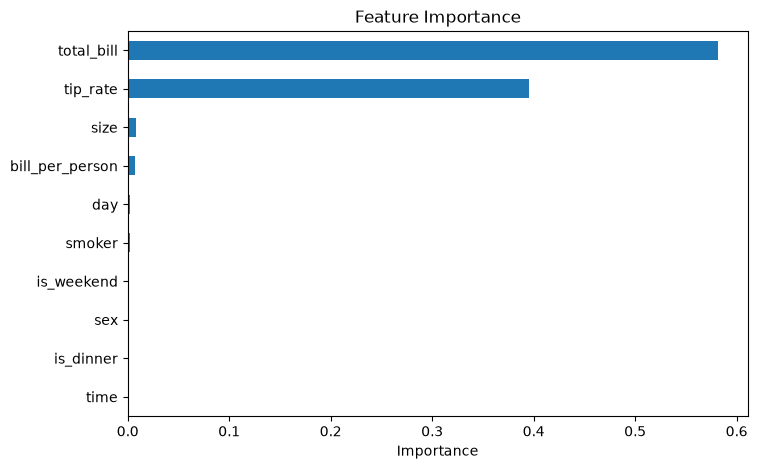

In [23]:
# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

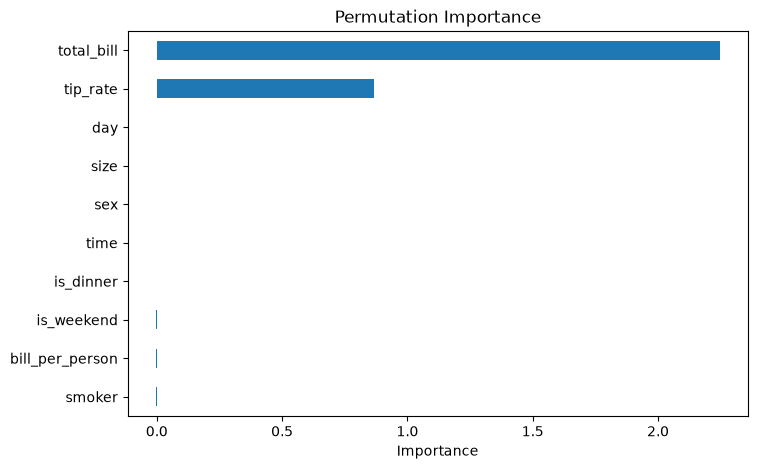

In [24]:
# 10. Permutation Importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.show()

In [29]:
# 11. 모델 저장
joblib.dump(model, "../model/tips_model02.pkl");
joblib.dump(encoders, "../model/tips_labelencoders02.pkl");

### 원핫인코딩

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder

In [31]:
df = pd.read_csv("../dataset/tips.csv")

In [36]:
# Feature Engineering
df['bill_per_person'] = df['total_bill'] / df['size']
df['is_weekend'] = df['day'].isin(['Sat', 'Sun']).astype(int)
df['is_dinner'] = (df['time'] == 'Dinner').astype(int)
df['tip_rate'] = df['tip'] / df['total_bill']

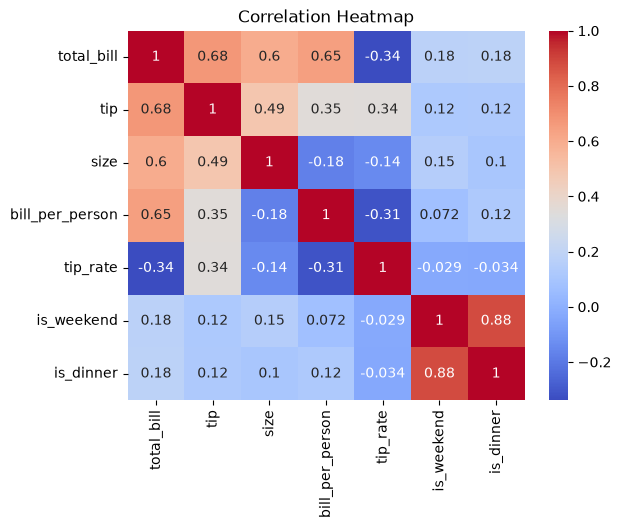

In [37]:
# 히트맵
plt.Figure(figsize=(8,6))

numeric_cols = [
    'total_bill', 'tip', 'size', 'bill_per_person', 'tip_rate', 'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [38]:
# OneHotEncoder 적용
categorical_cols = ['sex', 'smoker', 'day', 'time']

# 범주형 컬럼과 타깃 컬럼 tip을 제외한 나머지 컬럼을 가져옴
numeric_cols = df.columns.difference(categorical_cols + ['tip'])

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

df_encoded = pd.DataFrame(encoded, columns=encoded_cols)

# 기존 숫자형 + 인코딩 합치기
df_final = pd.concat([df[numeric_cols].reset_index(drop=True),
                      df_encoded.reset_index(drop=True)], axis=1)

print("\n===== OneHotEncoder 이후 데이터 =====")
print(df_final.head())


===== OneHotEncoder 이후 데이터 =====
   bill_per_person  is_dinner  is_seekend  ...  day_Sun  day_Thur  time_Lunch
0         8.495000          1           1  ...      1.0       0.0         0.0
1         3.446667          1           1  ...      1.0       0.0         0.0
2         7.003333          1           1  ...      1.0       0.0         0.0
3        11.840000          1           1  ...      1.0       0.0         0.0
4         6.147500          1           1  ...      1.0       0.0         0.0

[5 rows x 13 columns]


In [39]:
# X, y
X = df_final
y = df['tip']

In [40]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    random_state=42
)

In [42]:
# 모델 학습
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train, y_train)

# 평가
y_pred = model.predict(X_test)

print("\n===== 모델 성능 =====")
print(f"R2 Score: {r2_score(y_test, y_pred): .4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)): .4f}")


===== 모델 성능 =====
R2 Score:  0.8249
RMSE:  0.4679


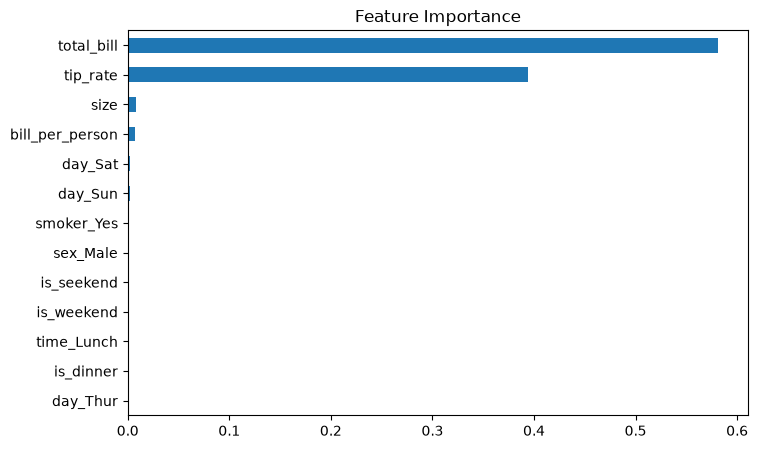

In [44]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

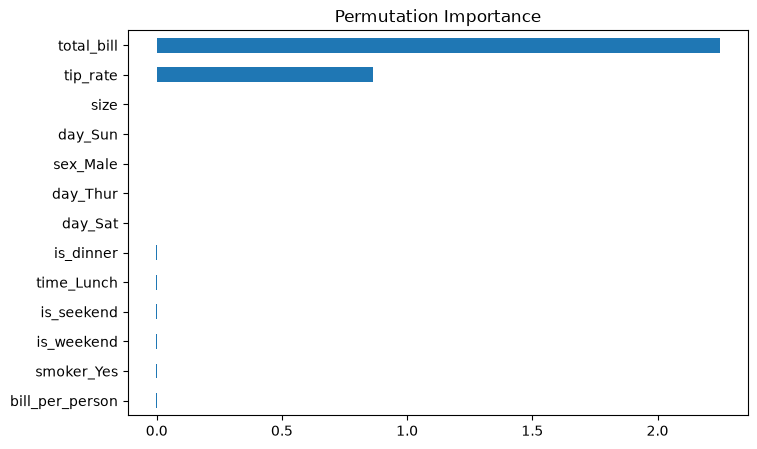

In [45]:
# Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,5))
perm_importance.sort_values().plot(kind='barh')
plt.title("Permutation Importance")
plt.show()

In [47]:
# 모델 저장
joblib.dump(model, "../model/tips_model02.pkl")
joblib.dump(encoders, "../model/tips_labelencoders02.pkl")

['../model/tips_labelencoders02.pkl']

### 랜덤포레스트를 활용한 당뇨병 데이터 알아보기 예제

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
# cross_val_score:파라미터를 사전 지정해서 교차검증, GridSearchCV : 하이퍼파라미터 조합 시도
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler    # 분류모델은 스케일러 효과 적음
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

In [49]:
data= pd.read_csv('../dataset/diabetes.csv')

In [50]:
# 특성(X)과 타겟(y) 분리
X = data.drop('Outcome', axis=1)
# cf. 특정 피처만 선별할 때 : X = data[['bmi', 'Glucose', 'Age']]
y = data['Outcome']

In [52]:
# 데이터 전처리 : 특성 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  
# 파라미터에 X를 그대로 집어넣는 것이 아니라 X_train을 나누고 집어넣었어야 함

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [53]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
# 랜덤 포레스트 모델 생성 및 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 모델 저장
# joblib.dump(model, '../model/diabetes_model.pkl')

# 예측
y_pred = rf_model.predict(X_test)

In [55]:
# 교차 검증 수행
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5)

In [56]:
# 특성 중요도 계산 (cf. permutation_importance : 다른 피처에 영향을 주는 정도를 측정)
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': rf_model.feature_importances_
}).sort_values('중요도', ascending=False)

In [58]:
# 결과 출력
print("모델 성능 평가:")
print("\n교차 검증 점수:")
print(f"평균 정확도: {cv_scores.mean(): .4f} (+/- {cv_scores.std()*2: .4f})")
print("\n분류 리포트:")
print(classification_report(y_test, y_pred))

모델 성능 평가:

교차 검증 점수:
평균 정확도:  0.7657 (+/-  0.0715)

분류 리포트:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



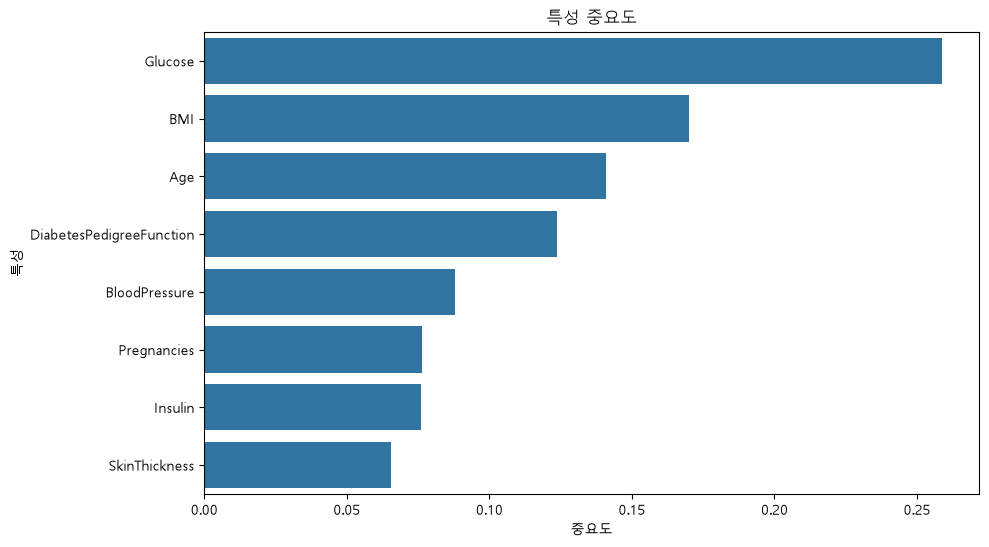

In [65]:
# 특성 중요도 시각화
plt.figure(figsize=(10,6))
sns.barplot(x='중요도', y='특성', data=feature_importance)
plt.title('특성 중요도')
plt.show()

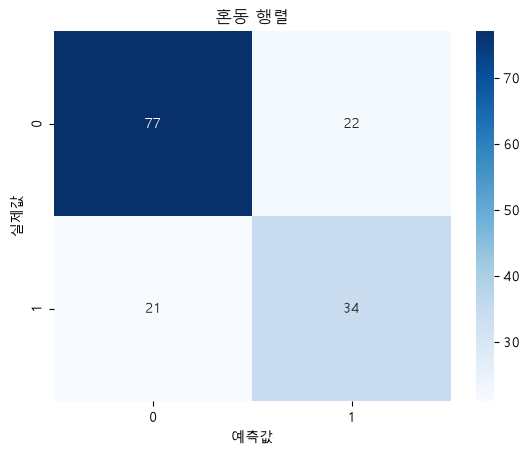

In [66]:
# 혼동 행렬 시각화
plt.Figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('혼동 행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.show()

In [67]:
# 새로운 환자 데이터로 예측 예시
print("새로운 환자 데이터 예측 예시")

# 임의의 환자 데이터 생성
new_patient = X_test.iloc[0:1]      # 첫 번째 인덱스 값
prediction = rf_model.predict(new_patient)
prediction_prob = rf_model.predict_proba(new_patient)

print(f"예측 결과: {'당뇨병 환자' if prediction[0] == 1 else '정상'}")
print(f"당뇨병일 확률: {prediction_prob[0][1]: .2%}")   # 첫 번째 샘플의 두 번째 클래스

새로운 환자 데이터 예측 예시
예측 결과: 정상
당뇨병일 확률:  31.00%


In [68]:
# 예측 신뢰도 분석
threshold_probs = rf_model.predict_proba(X_test)
confidence_scores = np.max(threshold_probs, axis=1)


예측 신뢰도 분포:


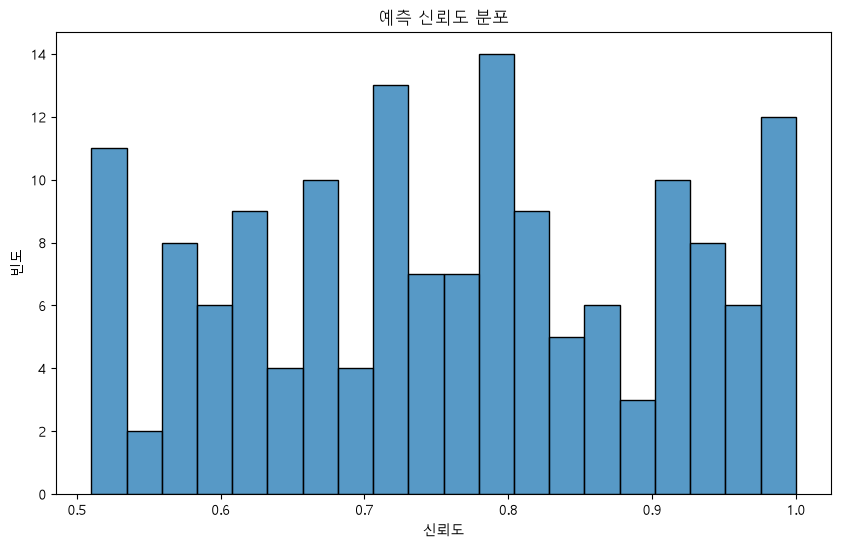

In [69]:
print("\n예측 신뢰도 분포:")
plt.figure(figsize=(10, 6))
sns.histplot(confidence_scores, bins=20)  # bins=20 : 데이터를 20개의 구간으로 보여줌
plt.title('예측 신뢰도 분포')
plt.xlabel('신뢰도')
plt.ylabel('빈도')
plt.show()

### 보스톤 집값 분석 예제

In [ ]:
### 컬럼 설명 ###
# CRIM(타운별 1인당 범죄율), ZN(25,000평방피트 주택이 차지하는 비율), INDUS(비소매 상업지역 면적비율)
# CHAS(찰스강 인접 여부), NOX(일산화질소 농도), RM(주택 1가구당 평균 방 개수), AGE(1940년대 이전 주택 비율)
# DIS(보스턴 고용 센터까지의 가중거리), RAD(고속도로 접근성 지수), TAX(10,000달러당 재산세율), PTRATIO(타운별 학생교사 비율)
# B(타운별 흑인인구 비율 계산식), LSTAT(하위 계층의 비율), MEDV(주택의 중간 가격)

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [72]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

In [74]:
data = pd.read_csv('../dataset/HousingData.csv')

In [75]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1,296,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2,242,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2,242,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3,222,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3,222,18.70,396.90,NaN,36.20


In [76]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [77]:
# 결측치 확인 및 처리
print(data.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [78]:
# 결측값 제거
data = data.dropna()

In [79]:
# 결측치 확인 및 처리
print(data.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [80]:
# 주요 변수 선택
# 입력 변수: CRIM(범죄율), RM(방개수), TAX(세금), LSTAT(하위계층비율)
X = data[['CRIM', 'RM', 'TAX', 'LSTAT']]
y = data['MEDV']    # 타겟 변수 : 집값

In [81]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 모델 예측 및 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [83]:
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 41.01145441904804
R2 Score: 0.5137736507938266


In [84]:
# 회귀 계수 출력
print("회귀 계수:", model.coef_)
print("절편:", model.intercept_)

회귀 계수: [-0.08498347  5.59693339 -0.00824347 -0.42511164]
절편: -3.831014747888208


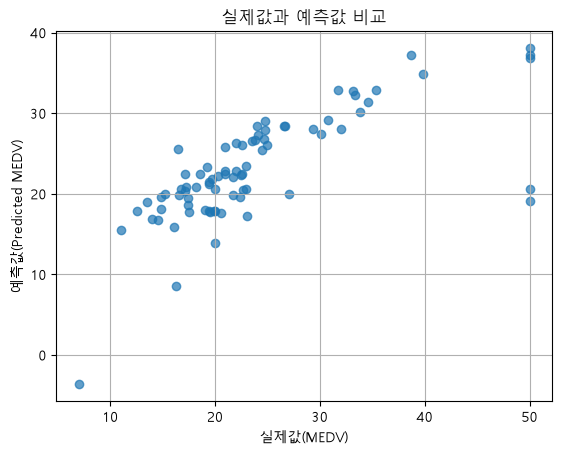

In [85]:
# 결과 시각화
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('실제값(MEDV)')
plt.ylabel('예측값(Predicted MEDV)')
plt.title('실제값과 예측값 비교')
plt.grid()
plt.show()

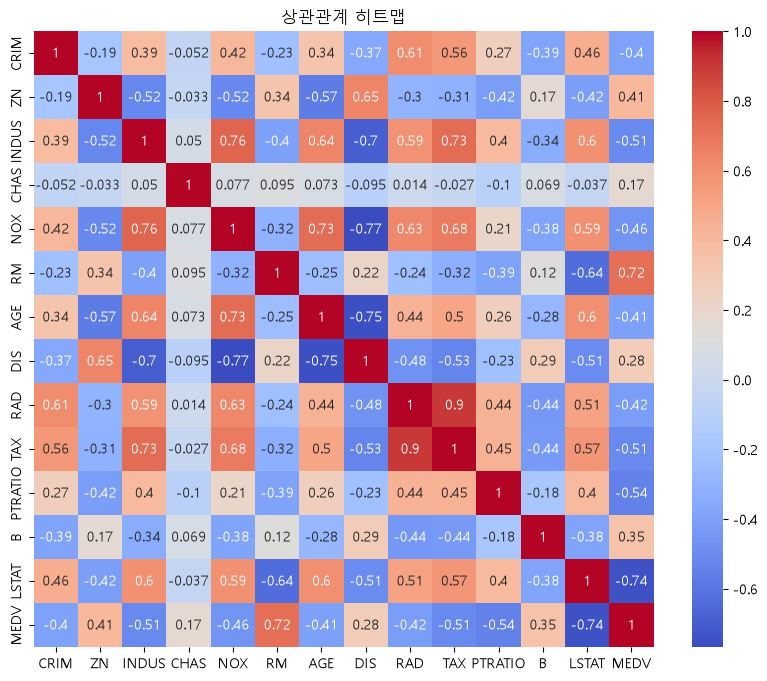

In [87]:
# 변수별 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('상관관계 히트맵')
plt.show()

### 랜덤포레스트 모델 활용한 예제(cf. 다른 회귀모델 성능 비교)

In [107]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [108]:
# 데이터 로드
data = pd.read_csv('../dataset/HousingData.csv')

In [109]:
# 데이터 전처리
data = data.dropna()  # 결측값 제거
X = data[['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'DIS', 'TAX', 'LSTAT']]
y = data['MEDV']

In [110]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [111]:
# 1. 랜덤 포레스트 모델
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

In [112]:
# 랜덤 포레스트 평가
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)
print(f"랜덤 포레스트 - MSE: {rf_mse:.2f}, R2: {rf_r2:.2f}")

랜덤 포레스트 - MSE: 28.57, R2: 0.66


In [113]:
# 2. 다른 모델 비교
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

In [114]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2": r2}
    print(f"{name} - MSE: {mse:.2f}, R2:{r2:.2f}")

Linear Regression - MSE: 36.34, R2:0.57
Decision Tree - MSE: 28.91, R2:0.66


In [115]:
# 3. 최적 모델 선택 및 시각화
results["Random Forest"] = {"MSE": rf_mse, "R2": rf_r2}

# R2를 기준으로 최적 모델 선택 (높을수록 좋음)
best_model = max(results, key=lambda x: results[x]['R2'])
print("최적 모델", best_model)

# MSE를 기준으로 최적 모델 선택 (낮을수록 좋음)
# best_model_mse = min(results, key=lambda x: results[x]['MSE'])
# print("[MSE 기준] 최적 모델:", best_model_mse)

최적 모델 Random Forest


In [116]:
# 결과 시각화
r2_scores = [result["R2"] for result in results.values()]
model_names = list(results.keys())
model_names

['Linear Regression', 'Decision Tree', 'Random Forest']

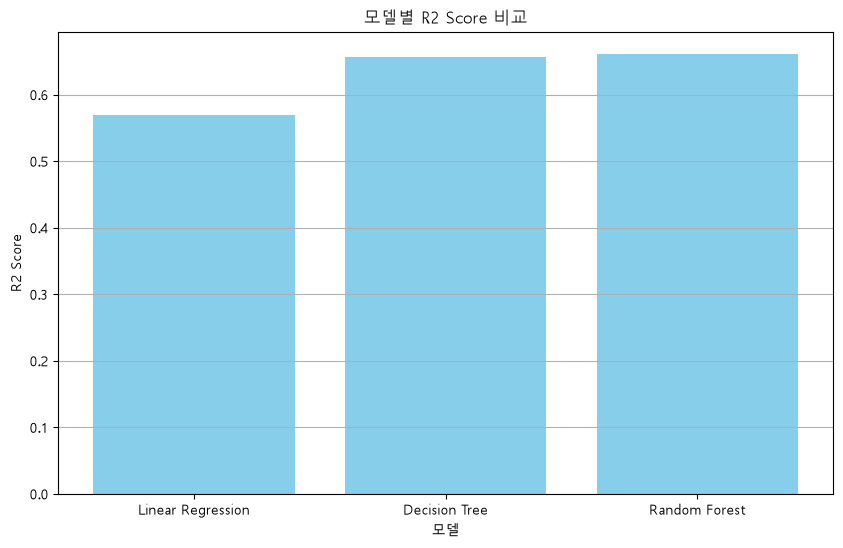

In [117]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("모델")
plt.ylabel("R2 Score")
plt.title("모델별 R2 Score 비교")
plt.grid(axis='y')
plt.show()

In [118]:
# 4. 랜덤 포레스트 하이퍼파라미터 튜닝 (옵션)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [121]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42), 
    param_grid=param_grid,
    cv=3,
    scoring='r2')
grid_search.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_
turnd_rf_y_pred = best_rf_model.predict(X_test)


최적 하이퍼파라미터: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


In [124]:
# 튜닝된 모델 평가
tuned_rf_mse = mean_squared_error(y_test, turnd_rf_y_pred)
tuned_rf_r2 = r2_score(y_test, turnd_rf_y_pred)
print(f"튜닝된 랜덤 포레스트 - MSE: {tuned_rf_mse:.2f}, R2: {tuned_rf_r2:.2f}")

튜닝된 랜덤 포레스트 - MSE: 28.54, R2: 0.66


### 직원 퇴사 예측 예제(개선 후: 원핫인코딩)

In [142]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [143]:
# 폰트 및 스타일 지정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.options.display.float_format = '{: .2f}'.format

In [144]:
# 데이터 로드 및 전처리
df = pd.read_csv('../dataset/HR_comma_sep.csv', encoding='cp949')

# 데이터셋 자체의 오타 및 공백 컬럼명을 표준 명칭으로 완벽하게 교정
df.rename(columns={
    'Departments ': 'Departments',
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'time_spent_company',
    'Work_accident': 'work_accident'
}, inplace=True)

# 'left' 열이 정수형인지 확인하고 변환
if df['left'].dtype != 'int64':
    df['left'] = df['left'].astype(int)
    
print(df.head())

   satisfaction_level  last_evaluation  ...  Departments  salary
0                0.38             0.53  ...        sales     low
1                0.80             0.86  ...        sales  medium
2                0.11             0.88  ...        sales  medium
3                0.72             0.87  ...        sales     low
4                0.37             0.52  ...        sales     low

[5 rows x 10 columns]


In [145]:
# 독립변수와 종속변수 설정
X = df.drop('left', axis=1)
y = df['left']

# 범주형 및 정제된 수치형 컬럼 리스트 분류(리네임되었으므로 자동 추출이 안전)
categorical_cols = ['Departments', 'salary']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print(f"추출된 수치형 변수 목록: {numeric_cols}")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

추출된 수치형 변수 목록: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spent_company', 'work_accident', 'promotion_last_5years']


In [147]:
# 인코딩 및 스케일링 (전처리 Pipeline 형태 구현)

# OneHotEncoder 정의 : Unknown 범주 대비 handel_unknown='ignore', 다중공선성 방지 drop='first'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# 학습 데이터의 범주형 변수 피팅 및 변환
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# 인코딩된 컬럼명 획득
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)

# 수치형 변수와 결합하여 새로운 DataFrame 생성
X_train_encoded = pd.concat([
    X_train[numeric_cols].reset_index(drop=True),
    pd.DataFrame(X_train_cat, columns=encoded_cat_cols)
], axis=1)

X_test_encoded = pd.concat([
    X_test[numeric_cols].reset_index(drop=True),
    pd.DataFrame(X_test_cat, columns=encoded_cat_cols)
], axis=1)

# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [149]:
# 모델 학습 : 랜덤포레스트
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 예측 및 평가
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.99

Confusion Matrix:
[[2286    8]
 [  27  679]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [151]:
# Feature Importance : 중요 변수 확인
feature_importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importance)

Feature Importances:
                    Feature  Importance
0        satisfaction_level        0.33
2            number_project        0.19
4        time_spent_company        0.18
3     average_monthly_hours        0.14
1           last_evaluation        0.12
5             work_accident        0.01
16               salary_low        0.01
15    Departments_technical        0.00
17            salary_medium        0.00
13        Departments_sales        0.00
14      Departments_support        0.00
7         Departments_RandD        0.00
8    Departments_accounting        0.00
6     promotion_last_5years        0.00
9            Departments_hr        0.00
10   Departments_management        0.00
11    Departments_marketing        0.00
12  Departments_product_mng        0.00


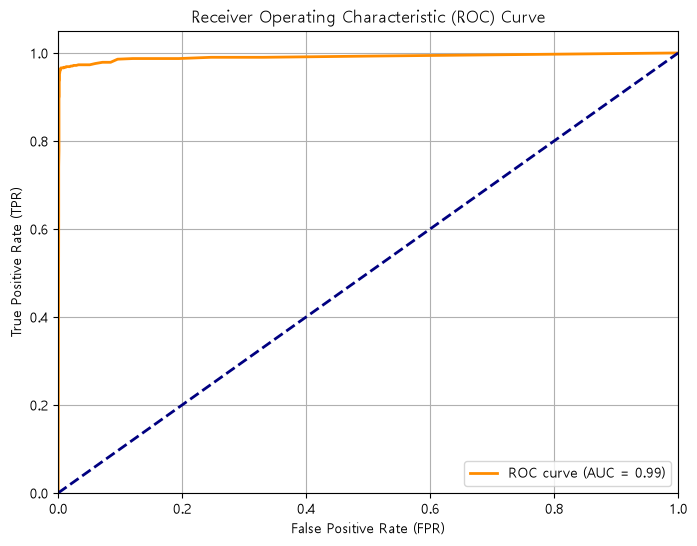

In [152]:
# ROC 커브 시각화
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [153]:
# 모델 및 전처리 객체 고유 파일 저장
joblib.dump(encoder, '../model/left_encoder.joblib')
joblib.dump(scaler, '../model/left_scaler.joblib')
joblib.dump(model, '../model/left_model.joblib')
# 시각화 용도로 사용할 인코딩된 피처 및 원본 컬럼 구조 저장
joblib.dump({'numeric_cols': numeric_cols, 
             'categorical_cols': categorical_cols}, 
             '../model/features_meta.joblib')

print("모든 모델 및 전처리 파일이 'model/' 폴더에 성공적으로 저장되었습니다.")

모든 모델 및 전처리 파일이 'model/' 폴더에 성공적으로 저장되었습니다.


### 자전거 수요량 예측(XGBoost)

In [ ]:
# 사전설치 : pip install xgboost

## 컬럼명,설명  ##
# season,계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울). 범주형 데이터.
# holiday,공휴일 여부 (0: 공휴일 아님, 1: 공휴일). 이진(binary) 데이터.
# workingday,근무일 여부 (0: 근무일 아님 (주말 또는 공휴일), 1: 근무일). 이진(binary) 데이터.
# weather,날씨 상태 (1: 맑음, 약간 흐림; 2: 안개, 흐림; 3: 약한 눈/비, 천둥번개; 4: 폭우/폭설, 안개). 범주형 데이터.
# temp,정규화된 온도 (섭씨). 0과 1 사이로 스케일링된 값. 실제 온도를 얻으려면 이 값에 스케일링 인자를 곱해야 할 수 있음.
# atemp,정규화된 체감 온도 (섭씨). 0과 1 사이로 스케일링된 값. 체감 온도는 바람, 습도 등을 고려한 온도.
# humidity,정규화된 습도. 0과 1 사이로 스케일링된 값.
# windspeed,정규화된 풍속. 0과 1 사이로 스케일링된 값.
# casual,비등록 사용자(회원이 아닌 사용자)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# registered,등록 사용자(회원)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# count,총 자전거 대여 건수 (casual + registered). 숫자형 데이터. 이 데이터셋에서 주요 예측 목표 변수(target variable)

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings('ignore')

In [2]:
# 데이터 불러오기
df = pd.read_csv('../dataset/bike.csv')
print(df.head())
print("데이터 크기:", df.shape)

              datetime  season  holiday  ...  casual  registered  count
0  2011-01-01 00:00:00       1        0  ...       3          13     16
1  2011-01-01 01:00:00       1        0  ...       8          32     40
2  2011-01-01 02:00:00       1        0  ...       5          27     32
3  2011-01-01 03:00:00       1        0  ...       3          10     13
4  2011-01-01 04:00:00       1        0  ...       0           1      1

[5 rows x 12 columns]
데이터 크기: (10886, 12)


In [5]:
# 간단한 전처리 및 새로운 피처 추가
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekend'] = df['datetime'].dt.weekday

In [ ]:
# 필요 없는 컬럼 제거
df = df.drop(['datatime', 'datetime', 'casual', 'registered'], axis=1)

In [8]:
# 로그 변환
# -> count가 편향되어 있으므로, 예로 특정시간대에는 많고, 새벽 등 다른 시간대에는 적은 경우, 
#    정규분포로 변환하여 모델학습 안정화

df['count'] = np.log1p(df['count'])

In [9]:
# X, y 분리
X = df.drop('count', axis=1)
y = df['count']

In [10]:
# 학습/검증 데이터 분리
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

In [11]:
# 표준화 : XGBoost에는 꼭 필요는 없지만 예시로 포함
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 하이퍼파라미터 튜닝 : GridSearchCV
# 제곱오차(reg:squarederror)로 MSE를 뜻함
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimator': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    # 각 트리 학습에 사용되는 데이터 샘플 비율, 과적합 방지
    'subsample': [0.8, 1],
    # 각 트리에서 사용되는 피처(변수)의 비율, 과적합 방지
    'colsample_bytree': [0.8, 1],
    # L1 정규화 (0: L1정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
    'alpha': [0, 1],
    # L2 정규화 (0: L2정규화 적용안함, 0.1~1: 약한 정규화, 1~10: 중간정규화, 10~100: 강한 정규화, 100이상: 매우강한 정규화)
    'lambda': [1, 10]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    # GridSearchCV는 점수가 높을수록 좋은 모델로 간주함으로 
    # RMSE에 negative(-)가 붙어서 덜 음수인 값이 더 나은 모델로 평가되도록 함
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    # n_jobs=1: 병렬처리 없이 단일 CPU코어로 순차적 학습
    # n_jobs=n: n개의 CPU코어로 사용, n_jobs=-1: 모든 CPU코어 사용
    n_jobs=1
)

grid.fit(X_train, y_train);
print("Best Parameters", grid.best_params)

Fitting 3 folds for each of 128 candidates, totalling 384 fits


AttributeError: 'GridSearchCV' object has no attribute 'best_params'